<a href="https://colab.research.google.com/github/rishavraj10264/Agricultural-Market-Price-Forecasting-System-/blob/main/Group8_secC3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing the Telengana market price raw data
along with some preprocessing

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving day_prices_between_01-11-2025_30-11-2025.csv to day_prices_between_01-11-2025_30-11-2025.csv
Saving day_prices_between_01-10-2025_31-10-2025.csv to day_prices_between_01-10-2025_31-10-2025.csv
Saving day_prices_between_01-09-2025_30-09-2025.csv to day_prices_between_01-09-2025_30-09-2025.csv
Saving day_prices_between_01-08-2025_31-08-2025.csv to day_prices_between_01-08-2025_31-08-2025.csv
Saving day_prices_between_01-07-2025_31-07-2025.csv to day_prices_between_01-07-2025_31-07-2025.csv
Saving day_prices_between_01-06-2025_30-06-2025.csv to day_prices_between_01-06-2025_30-06-2025.csv
Saving day_prices_between_01-05-2025_31-05-2025.csv to day_prices_between_01-05-2025_31-05-2025.csv
Saving day_prices_between_01-04-2025_30-04-2025.csv to day_prices_between_01-04-2025_30-04-2025.csv
Saving day_prices_between_01-03-2025_31-03-2025.csv to day_prices_between_01-03-2025_31-03-2025.csv
Saving day_prices_between_01-02-2025_28-02-2025.csv to day_prices_between_01-02-2025_28-02-2025.csv


In [ ]:
import pandas as pd
import glob
import os


In [ ]:
# Get all uploaded CSV files
csv_files = glob.glob("*.csv")

print(f"Found {len(csv_files)} CSV files:")
for f in csv_files:
    print(f)

# Load each CSV
dfs = []
for file in csv_files:
    df = pd.read_csv(file)
    df["source_file"] = file   # optional (debugging / traceability)
    dfs.append(df)

# Merge all files
merged = pd.concat(dfs, ignore_index=True)
print("Rows after merging:", len(merged))


Found 60 CSV files:
day_prices_between_01-09-2025_30-09-2025.csv
day_prices_between_01-04-2023_30-04-2023.csv
day_prices_between_01-08-2025_31-08-2025.csv
day_prices_between_01-02-2021_28-02-2021.csv
day_prices_between_01-10-2025_31-10-2025.csv
day_prices_between_01-03-2022_31-03-2022.csv
day_prices_between_01-12-2022_31-12-2022.csv
day_prices_between_01-11-2022_30-11-2022.csv
day_prices_between_01-04-2024_30-04-2024.csv
day_prices_between_01-07-2023_31-07-2023.csv
day_prices_between_01-08-2022_31-08-2022.csv
day_prices_between_01-10-2022_31-10-2022.csv
day_prices_between_01-05-2025_31-05-2025.csv
day_prices_between_01-03-2021_31-03-2021.csv
day_prices_between_01-06-2022_30-06-2022.csv
day_prices_between_01-08-2021_31-08-2021.csv
day_prices_between_01-12-2021_31-12-2021.csv
day_prices_between_01-10-2024_31-10-2024.csv
day_prices_between_01-02-2022_28-02-2022.csv
day_prices_between_01-08-2023_31-08-2023.csv
day_prices_between_01-09-2022_30-09-2022.csv
day_prices_between_01-12-2023_31-12

Renaming columns

In [ ]:
def clean_market_data(df):
    df = df.copy()

    # Rename columns (standard names)
    df = df.rename(columns={
        'DDate': 'date',
        'AmcCode': 'amc_code',
        'AmcName': 'amc_name',
        'YardCode': 'yard_code',
        'YardName': 'yard_name',
        'CommCode': 'commodity_code',
        'CommName': 'commodity',
        'VarityCode': 'variety_code',
        'VarityName': 'variety',
        'Arrivals': 'arrivals',
        'Minimum': 'min_price',
        'Maximum': 'max_price',
        'Model': 'modal_price'
    })

    # Check for and handle duplicate columns
    if not df.columns.is_unique:
        print("Warning: DataFrame has duplicate columns after renaming. Keeping the first occurrence.")
        # Get a boolean mask of unique columns (keeping the first occurrence)
        df = df.loc[:, ~df.columns.duplicated()]

    # Convert date
    df['date'] = pd.to_datetime(df['date'], errors='coerce')

    # Convert numeric columns
    numeric_cols = ['arrivals', 'min_price', 'max_price', 'modal_price']
    for col in numeric_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    # Remove duplicates
    df = df.drop_duplicates()

    # Remove invalid rows
    df = df.dropna(subset=['date', 'modal_price'])
    df = df[df['modal_price'] > 0]

    # Handle arrivals
    df['arrivals_missing'] = df['arrivals'].isna().astype(int)
    df['arrivals'] = df['arrivals'].fillna(0)

    # Sort for time-series correctness
    df = df.sort_values(
        ['commodity', 'yard_name', 'variety', 'date']
    ).reset_index(drop=True)

    return df

cleaned = clean_market_data(merged)

print("Rows after cleaning:", len(cleaned))
print("Date range:", cleaned['date'].min(), "to", cleaned['date'].max())

Rows after cleaning: 498029
Date range: 2021-01-01 00:00:00+05:30 to 2025-11-30 00:00:00+05:30


In [ ]:
print(cleaned.head())
print(cleaned.tail())
print("\nMissing values:\n", cleaned.isna().sum())


                       date  amc_code  amc_name  yard_code yard_name  \
0 2021-03-09 00:00:00+05:30       314  Marpally         45  Marpally   
1 2021-03-16 00:00:00+05:30       314  Marpally         45  Marpally   
2 2021-03-23 00:00:00+05:30       314  Marpally         45  Marpally   
3 2021-03-30 00:00:00+05:30       314  Marpally         45  Marpally   
4 2021-04-06 00:00:00+05:30       314  Marpally         45  Marpally   

   commodity_code commodity  variety_code variety  ProgArrivals  arrivals  \
0             219     Ajwan           269  Common           0.0      11.0   
1             219     Ajwan           269  Common           0.0      12.0   
2             219     Ajwan           269  Common           0.0      10.0   
3             219     Ajwan           269  Common           0.0      15.0   
4             219     Ajwan           269  Common           0.0       8.0   

   min_price  max_price  modal_price  Valuation  MarketFee  \
0    11000.0    14000.0      12000.0      

In [ ]:
output_file = "telangana_market_prices_2021_2025_clean.csv"
cleaned.to_csv(output_file, index=False)

print("✅ Clean dataset saved successfully:", output_file)


✅ Clean dataset saved successfully: telangana_market_prices_2021_2025_clean.csv


In [ ]:
files.download(output_file)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**EDA**

In [ ]:
df.shape
df.info()
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10530 entries, 0 to 10529
Data columns (total 17 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   DDate         10530 non-null  object 
 1   AmcCode       10530 non-null  int64  
 2   AmcName       10530 non-null  object 
 3   YardCode      10530 non-null  int64  
 4   YardName      10530 non-null  object 
 5   CommCode      10530 non-null  int64  
 6   CommName      10530 non-null  object 
 7   VarityCode    10530 non-null  int64  
 8   VarityName    10530 non-null  object 
 9   ProgArrivals  10530 non-null  float64
 10  Arrivals      10530 non-null  float64
 11  Minimum       10530 non-null  float64
 12  Maximum       10530 non-null  float64
 13  Model         10530 non-null  float64
 14  Valuation     10530 non-null  float64
 15  MarketFee     10530 non-null  float64
 16  source_file   10530 non-null  object 
dtypes: float64(7), int64(4), object(6)
memory usage: 1.4+ MB


,DDate,AmcCode,AmcName,YardCode,YardName,CommCode,CommName,VarityCode,VarityName,ProgArrivals,Arrivals,Minimum,Maximum,Model,Valuation,MarketFee,source_file
0,2022-05-01 00:00:00+05:30,323,Gaddiannaram,2,L.B Nagar,98,Cabbage,98,Common,0.0,15.0,500.0,800.0,600.0,0.0,0.0,day_prices_between_01-05-2022_31-05-2022.csv
1,2022-05-01 00:00:00+05:30,323,Gaddiannaram,1,Gaddiannaram,76,Mango,291,Benishan,0.0,6506.0,1250.0,8000.0,4000.0,0.0,0.0,day_prices_between_01-05-2022_31-05-2022.csv
2,2022-05-01 00:00:00+05:30,325,Hyderabad,7,Meeralamandi,98,Cabbage,98,Common,0.0,5.0,1000.0,1200.0,1100.0,0.0,0.0,day_prices_between_01-05-2022_31-05-2022.csv
3,2022-05-01 00:00:00+05:30,316,Narsingi,49,Babbuguda,168,Cattle(All),168,Common,0.0,198.0,20000.0,50000.0,30000.0,0.0,0.0,day_prices_between_01-05-2022_31-05-2022.csv
4,2022-05-01 00:00:00+05:30,313,Ibrahimpatnam(RR),42,Ibrahimpatnam,111,Brinjal,111,Common,0.0,6.0,1000.0,2000.0,1500.0,0.0,0.0,day_prices_between_01-05-2022_31-05-2022.csv


In [ ]:
df.isna().sum().sort_values(ascending=False)


,0
DDate,0
AmcCode,0
AmcName,0
YardCode,0
YardName,0
CommCode,0
CommName,0
VarityCode,0
VarityName,0
ProgArrivals,0


In [ ]:
cleaned[['modal_price','arrivals','min_price','max_price']].describe()

,modal_price,arrivals,min_price,max_price
count,4.980290e+05,4.980290e+05,4.980290e+05,4.980290e+05
mean,3.489090e+03,3.843608e+02,5.020053e+07,3.815859e+03
std,8.322275e+04,4.244192e+03,3.542523e+10,4.874307e+03
min,1.000000e+00,1.000000e-03,0.000000e+00,0.000000e+00
25%,1.400000e+03,9.000000e+00,1.000000e+03,1.602000e+03
50%,2.200000e+03,4.000000e+01,1.900000e+03,2.500000e+03
75%,4.000000e+03,2.270000e+02,3.200000e+03,5.000000e+03
max,5.426152e+07,1.743030e+06,2.500000e+13,1.501500e+06


In [ ]:
df_sub = cleaned[
    cleaned['variety'].str.contains('common', case=False, na=False)
].copy()

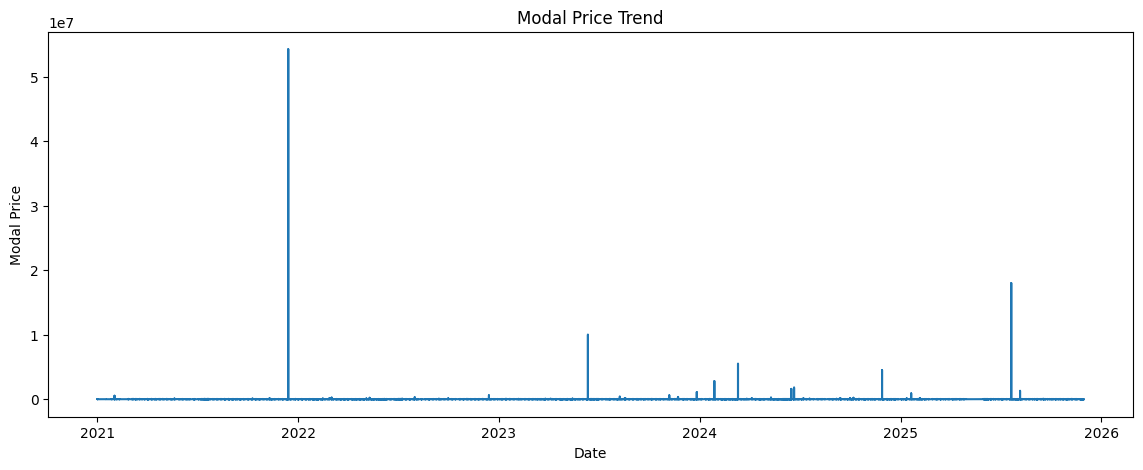

In [ ]:
import matplotlib.pyplot as plt

df_sub = df_sub.sort_values('date')

plt.figure(figsize=(14,5))
plt.plot(df_sub['date'], df_sub['modal_price'])
plt.title("Modal Price Trend")
plt.xlabel("Date")
plt.ylabel("Modal Price")
plt.show()

In [ ]:
upper = df_sub['modal_price'].quantile(0.99)
df_sub['modal_price_clipped'] = df_sub['modal_price'].clip(upper=upper)


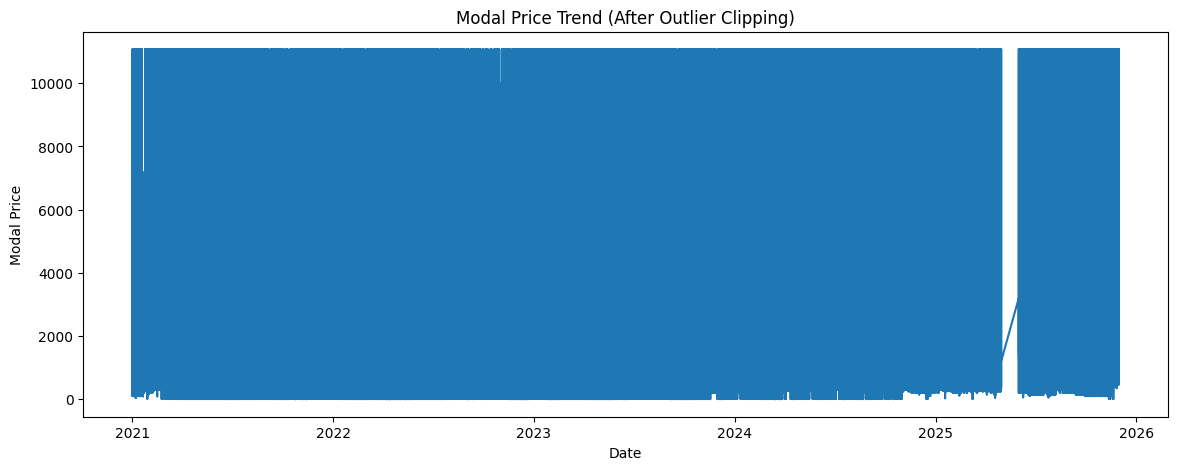

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df_sub['date'], df_sub['modal_price_clipped'])
plt.title("Modal Price Trend (After Outlier Clipping)")
plt.xlabel("Date")
plt.ylabel("Modal Price")
plt.show()


In [ ]:
import numpy as np
df_sub['log_modal_price'] = np.log1p(df_sub['modal_price'])


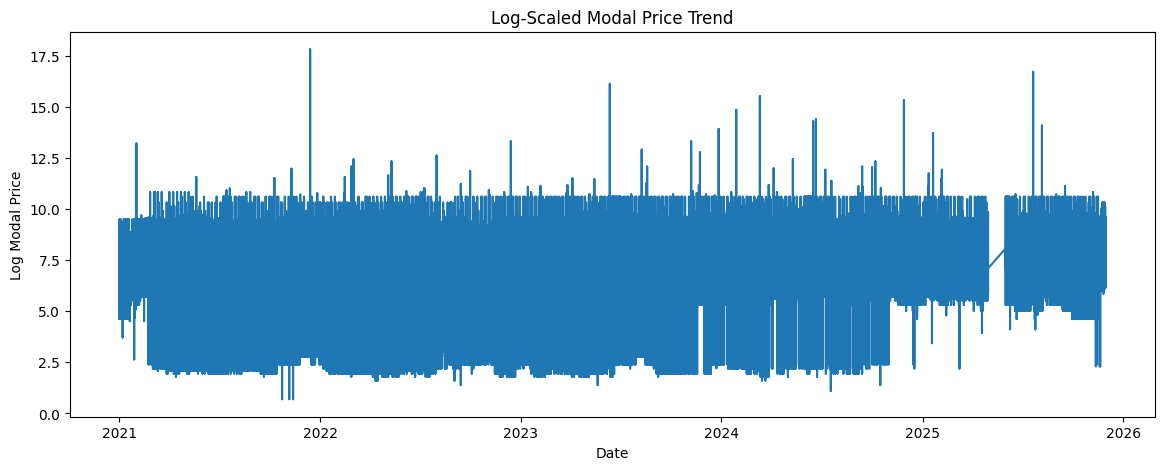

In [ ]:
plt.figure(figsize=(14,5))
plt.plot(df_sub['date'], df_sub['log_modal_price'])
plt.title("Log-Scaled Modal Price Trend")
plt.xlabel("Date")
plt.ylabel("Log Modal Price")
plt.show()


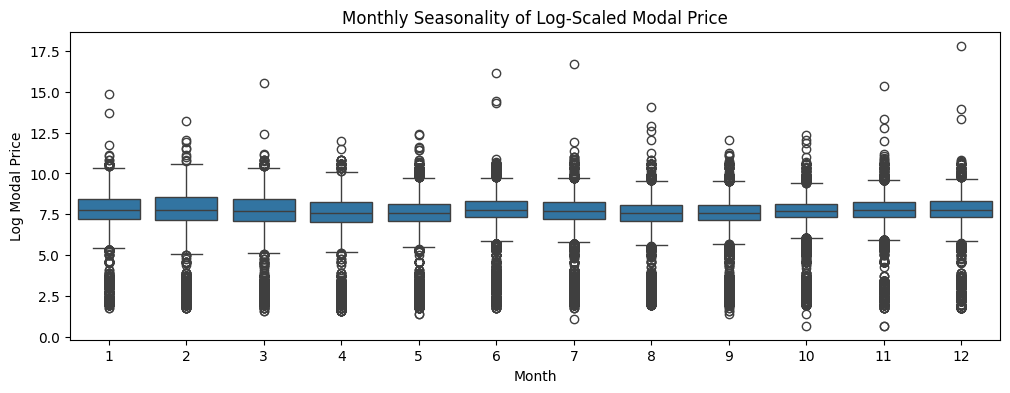

In [ ]:
df_sub['month'] = df_sub['date'].dt.month

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,4))
sns.boxplot(
    x='month',
    y='log_modal_price',
    data=df_sub
)
plt.title("Monthly Seasonality of Log-Scaled Modal Price")
plt.xlabel("Month")
plt.ylabel("Log Modal Price")
plt.show()


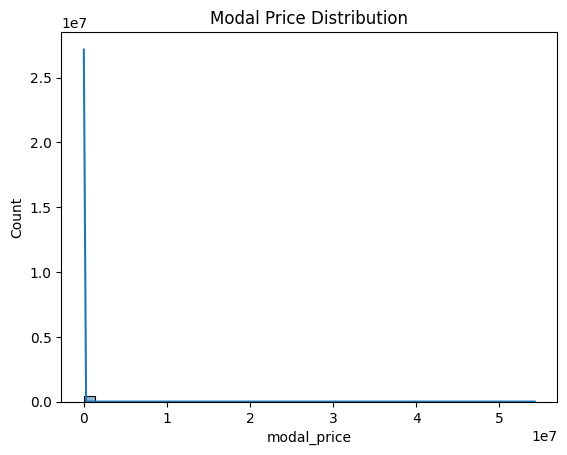

In [ ]:
sns.histplot(df_sub['modal_price'], bins=40, kde=True)
plt.title("Modal Price Distribution")
plt.show()


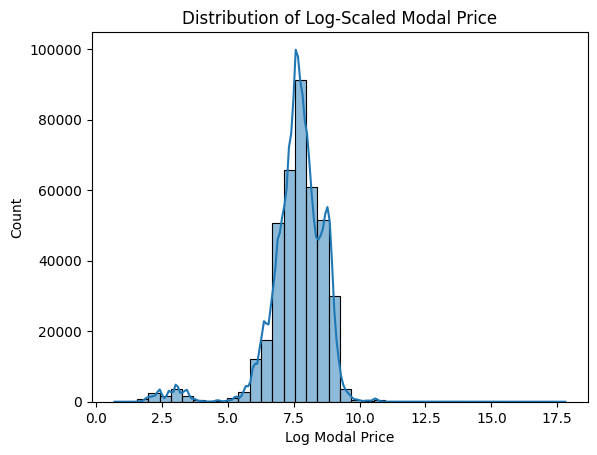

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df_sub['log_modal_price'], bins=40, kde=True)
plt.title("Distribution of Log-Scaled Modal Price")
plt.xlabel("Log Modal Price")
plt.show()


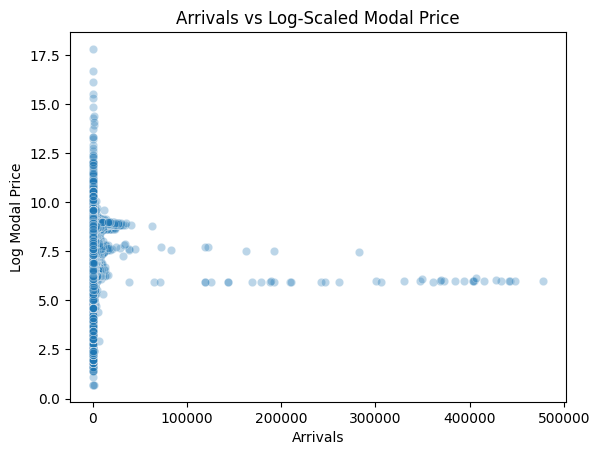

In [ ]:


sns.scatterplot(
    x='arrivals',
    y='log_modal_price',
    data=df_sub,
    alpha=0.3
)
plt.title("Arrivals vs Log-Scaled Modal Price")
plt.xlabel("Arrivals")
plt.ylabel("Log Modal Price")
plt.show()


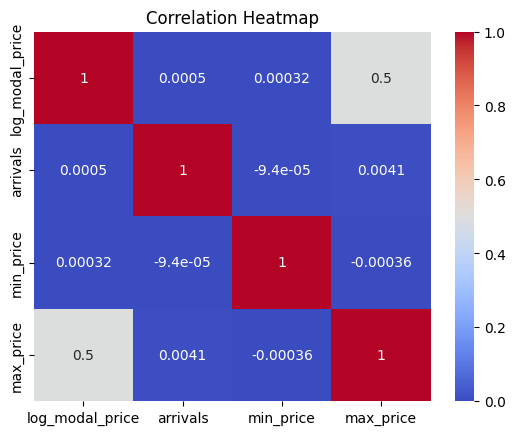

In [ ]:
corr_cols = [
    'log_modal_price',
    'arrivals',
    'min_price',
    'max_price'
]

sns.heatmap(
    df_sub[corr_cols].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Correlation Heatmap")
plt.show()


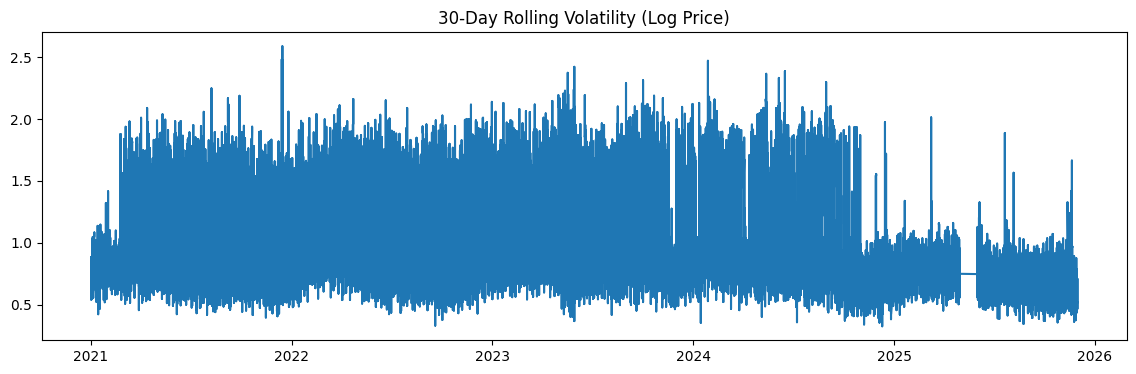

In [ ]:
df_sub['rolling_std_30'] = df_sub['log_modal_price'].rolling(30).std()

plt.figure(figsize=(14,4))
plt.plot(df_sub['date'], df_sub['rolling_std_30'])
plt.title("30-Day Rolling Volatility (Log Price)")
plt.show()


In [ ]:
df_sub.groupby('yard_name')['log_modal_price'].mean().sort_values().head(10)

,log_modal_price
yard_name,
V Nagar,2.870183
Nakrekal,5.624139
Sattupalli,6.205675
Madhira,6.463475
Jainath,6.614510
Mallial,7.214907
Vantimamidi,7.228588
Gudumalkapur,7.313485
Meeralamandi,7.366167


In [ ]:
df_sub.isna().sum()


,0
date,0
amc_code,0
amc_name,0
yard_code,0
yard_name,0
commodity_code,0
commodity,0
variety_code,0
variety,0
ProgArrivals,10504


In [ ]:
drop_cols = [
    'source_file',
    'MarketFee',
    'Valuation',
    'ProgArrivals'
]

df = df.drop(columns=drop_cols)


In [ ]:
df_sub = df_sub.sort_values('date').reset_index(drop=True)


In [ ]:
df_sub = df_sub.drop(columns=['modal_price', 'modal_price_clipped'])


In [ ]:
# Clean categorical text columns
df_sub['commodity_clean'] = df_sub['commodity'].str.strip().str.lower()
df_sub['variety_clean'] = df_sub['variety'].str.strip().str.lower()
df_sub['yard_clean'] = df_sub['yard_name'].str.strip().str.lower()


In [ ]:
df_model = df_sub[
    (df_sub['commodity_clean'].str.contains('paddy')) &
    (df_sub['variety_clean'] == 'common')
].copy()


In [ ]:
# Check top markets by data size
df_model['yard_name'].value_counts().head(10)


,count
yard_name,
Mothkur,858
Thorruru,584
Kodakandala,560
Tandur,335
Shadnagar,315
Asifabad,302
Luxettipet,242
Chennur,236
Maddulapally,230


In [ ]:
df_model = df_model.sort_values('date').reset_index(drop=True)


In [ ]:
keep_cols = [
    'date',
    'log_modal_price',
    'arrivals',
    'min_price',
    'max_price'
]

df_model = df_model[keep_cols]


In [ ]:
print("Final dataset shape:", df_model.shape)
df_model.head()


Final dataset shape: (4686, 5)


,date,log_modal_price,arrivals,min_price,max_price
0,2021-01-02 00:00:00+05:30,7.496097,15.5,1800.0,1800.0
1,2021-01-04 00:00:00+05:30,7.445418,33.0,1353.0,1742.0
2,2021-01-04 00:00:00+05:30,7.555905,151.0,1301.0,1941.0
3,2021-01-04 00:00:00+05:30,7.421178,32.0,1650.0,1800.0
4,2021-01-05 00:00:00+05:30,7.249215,48.0,1406.0,1456.0


Feature Engeeninring


In [ ]:
##create time based features
import numpy as np

# Calendar features
df_model['month'] = df_model['date'].dt.month
df_model['day_of_year'] = df_model['date'].dt.dayofyear

# Cyclical encoding
df_model['month_sin'] = np.sin(2 * np.pi * df_model['month'] / 12)
df_model['month_cos'] = np.cos(2 * np.pi * df_model['month'] / 12)

df_model['day_of_week'] = df_model['date'].dt.dayofweek
df_model['dow_sin'] = np.sin(2*np.pi*df_model['day_of_week']/7)
df_model['dow_cos'] = np.cos(2*np.pi*df_model['day_of_week']/7)



In [ ]:
#Lag features
LAGS = [1, 7, 14, 30]

for lag in LAGS:
    df_model[f'lag_{lag}'] = df_model['log_modal_price'].shift(lag)



In [ ]:
#Rolling statistics
# Rolling means
df_model['roll_mean_7']  = df_model['log_modal_price'].rolling(7).mean()
df_model['roll_mean_30'] = df_model['log_modal_price'].rolling(30).mean()

# Rolling volatility
df_model['roll_std_30'] = df_model['log_modal_price'].rolling(30).std()


In [ ]:
#drop raw columns
df_model = df_model.drop(columns=[
    'arrivals',
    'min_price',
    'max_price',
    'month',
    'price_range'
], errors='ignore')

In [ ]:
#Remove rows with NaNs (created by lags & rolling)
df_model = df_model.dropna().reset_index(drop=True)


In [ ]:
#Final feature set check
print("Final feature dataset shape:", df_model.shape)
df_model.head()


Final feature dataset shape: (4656, 15)


,date,log_modal_price,day_of_year,month_sin,month_cos,day_of_week,dow_sin,dow_cos,lag_1,lag_7,lag_14,lag_30,roll_mean_7,roll_mean_30,roll_std_30
0,2021-02-13 00:00:00+05:30,7.195187,44,0.866025,0.5,5,-0.974928,-0.222521,7.555905,7.479300,7.496097,7.496097,7.419723,7.434185,0.094080
1,2021-02-15 00:00:00+05:30,7.430114,46,0.866025,0.5,0,0.000000,1.000000,7.195187,7.415175,7.347944,7.445418,7.421857,7.433674,0.094059
2,2021-02-16 00:00:00+05:30,7.320527,47,0.866025,0.5,1,0.781831,0.623490,7.430114,7.515345,7.504942,7.555905,7.394026,7.425828,0.093325
3,2021-02-22 00:00:00+05:30,7.307202,53,0.866025,0.5,0,0.000000,1.000000,7.320527,7.479300,7.424165,7.421178,7.369440,7.422029,0.095808
4,2021-02-23 00:00:00+05:30,7.543803,54,0.866025,0.5,1,0.781831,0.623490,7.307202,7.337588,7.534228,7.249215,7.398900,7.431849,0.092526


Separate features and target

In [ ]:
import numpy as np
import pandas as pd

X = df_model.drop(columns=['date', 'log_modal_price'])
y = df_model['log_modal_price']


In [ ]:
lower = y.quantile(0.01)
upper = y.quantile(0.99)

y = y.clip(lower, upper)


In [ ]:
y = y.rolling(window=3).mean()
y = y.dropna()
X = X[2:]


In [ ]:
split = int(len(X) * 0.8)

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


Feature scaling

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Scale X
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test  = scaler_X.transform(X_test)

# Scale y (VERY IMPORTANT)
scaler_y = MinMaxScaler()
y_train = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test  = scaler_y.transform(y_test.values.reshape(-1,1))

Create sequences (sliding window)

In [ ]:
LOOKBACK = 20

def create_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(len(X) - lookback):
        Xs.append(X[i:i+lookback])
        ys.append(y[i+lookback])
    return np.array(Xs), np.array(ys)

X_train_seq, y_train_seq = create_sequences(X_train, y_train, LOOKBACK)
X_test_seq,  y_test_seq  = create_sequences(X_test, y_test, LOOKBACK)


 GRU model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_1 = Sequential([
    GRU(
        64,
        return_sequences=True,
        input_shape=(LOOKBACK, X_train_seq.shape[2])
    ),
    Dropout(0.2),

    GRU(32),
    Dropout(0.2),

    Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0003)

model_1.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

model_1.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_2 (GRU)                     │ (None, 20, 64)         │        15,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,609 (96.13 KB)

 Trainable params: 24,609 (96.13 KB)

 Non-trainable params: 0 (0.00 B)

Train the model

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-5,
)


In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model_1.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=32,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

y_pred_scaled = model_1.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)



Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - loss: 0.0891 - mae: 0.3454 - val_loss: 0.0108 - val_mae: 0.1128 - learning_rate: 3.0000e-04
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms/step - loss: 0.0231 - mae: 0.1683 - val_loss: 0.0106 - val_mae: 0.1098 - learning_rate: 3.0000e-04
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0177 - mae: 0.1475 - val_loss: 0.0086 - val_mae: 0.0973 - learning_rate: 3.0000e-04
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0130 - mae: 0.1272 - val_loss: 0.0096 - val_mae: 0.1041 - learning_rate: 3.0000e-04
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0118 - mae: 0.1221 - val_loss: 0.0077 - val_mae: 0.0919 - learning_rate: 3.0000e-04
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0095 - mae: 0.1086 - val_loss: 0.0066 - val_mae: 0.0861 - learning_rate: 3.0000e-04
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0094 - mae: 0.1071 - val_loss: 0.0064 - val_mae: 0.0839

Evaluate the model

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np


rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae  = mean_absolute_error(y_test_actual, y_pred)
r2   = r2_score(y_test_actual, y_pred)

print(f"GRU RMSE: {rmse:.4f}")
print(f"GRU MAE : {mae:.4f}")
print(f"GRU R²  : {r2:.4f}")


GRU RMSE: 0.0626
GRU MAE : 0.0466
GRU R²  : 0.4713


Plot predictions vs actual

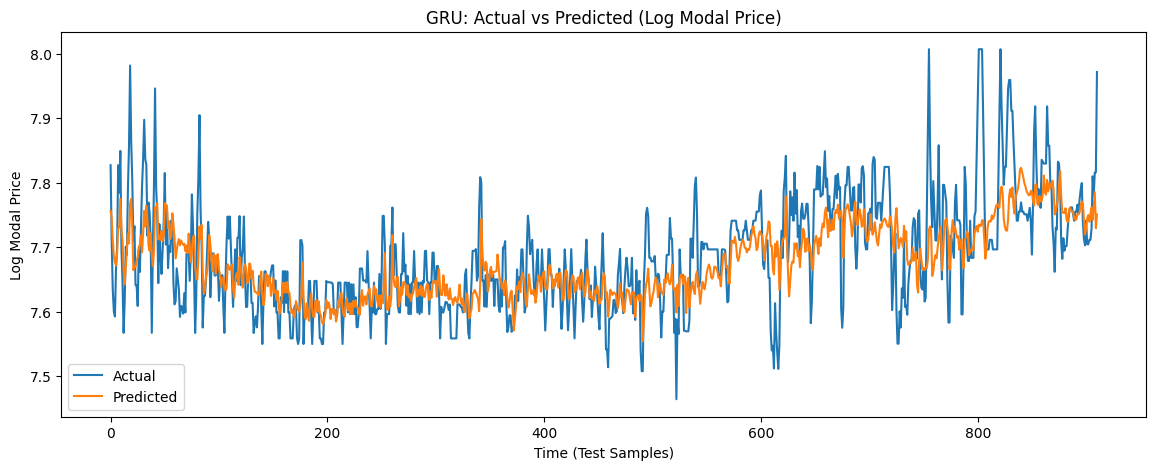

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.title("GRU: Actual vs Predicted (Log Modal Price)")
plt.xlabel("Time (Test Samples)")
plt.ylabel("Log Modal Price")
plt.legend()
plt.show()


LSTM model

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_2 = Sequential([
    LSTM(
        64,
        return_sequences=True,
        input_shape=(LOOKBACK, X_train_seq.shape[2])
    ),
    Dropout(0.2),

    LSTM(32),
    Dropout(0.2),

    Dense(1)   # linear output (IMPORTANT)
])

model_2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0003),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

model_2.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 20, 64)         │        19,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 20, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,417 (126.63 KB)

 Trainable params: 32,417 (126.63 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model_2.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop]
)


Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - loss: 0.0748 - mae: 0.3235 - val_loss: 0.0426 - val_mae: 0.2519
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0257 - mae: 0.1780 - val_loss: 0.0104 - val_mae: 0.1082
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0143 - mae: 0.1342 - val_loss: 0.0076 - val_mae: 0.0938
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0112 - mae: 0.1191 - val_loss: 0.0069 - val_mae: 0.0889
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 0.0107 - mae: 0.1152 - val_loss: 0.0067 - val_mae: 0.0871
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 0.0102 - mae: 0.1137 - val_loss: 0.0065 - val_mae: 0.0866
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0092 - mae: 0.1085 - val_loss: 0.0066 - val_mae: 0.0868
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0088 - mae: 0.1050 - val_loss: 0.0069 - val_mae: 0.0885
Epoch 9/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 20ms/

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict (scaled)
y_pred_scaled = model_2.predict(X_test_seq)

# Inverse transform
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae  = mean_absolute_error(y_test_actual, y_pred)
r2   = r2_score(y_test_actual, y_pred)

print(f"LSTM RMSE: {rmse:.4f}")
print(f"LSTM MAE : {mae:.4f}")
print(f"LSTM R²  : {r2:.4f}")


29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
LSTM RMSE: 0.0668
LSTM MAE : 0.0507
LSTM R²  : 0.3981


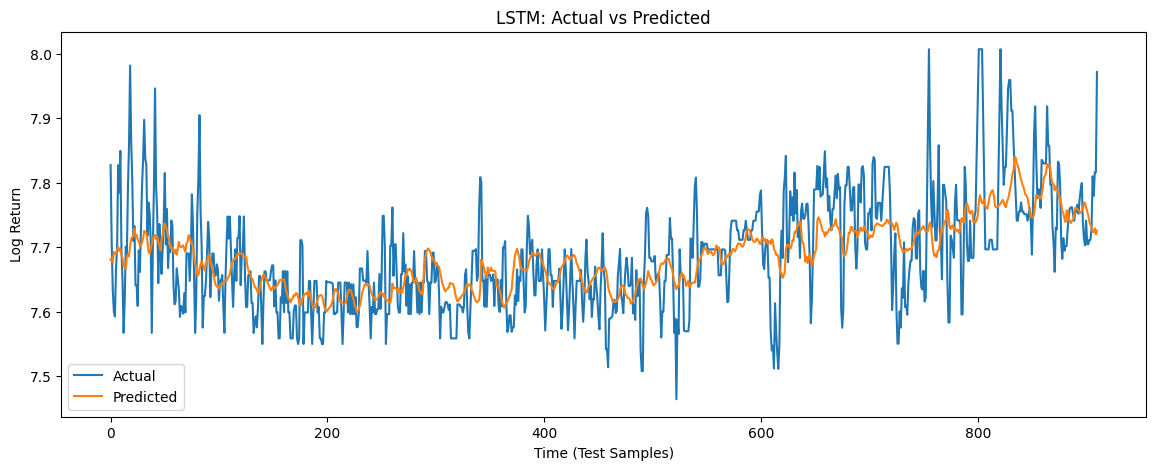

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.xlabel("Time (Test Samples)")
plt.ylabel("Log Return")
plt.title("LSTM: Actual vs Predicted")
plt.legend()
plt.show()


Transformer


In [ ]:
import tensorflow as tf
from tensorflow.keras.layers import Layer

class PositionalEncoding(Layer):
    def __init__(self, sequence_len, d_model):
        super().__init__()
        pos = tf.range(sequence_len)[:, tf.newaxis]
        i = tf.range(d_model)[tf.newaxis, :]
        # Cast the numerator to float32 to match the denominator's dtype
        angle_rates = 1 / tf.pow(10000.0, tf.cast((2 * (i // 2)), tf.float32) / tf.cast(d_model, tf.float32))
        angle_rads = tf.cast(pos, tf.float32) * angle_rates

        sines = tf.sin(angle_rads[:, 0::2])
        cosines = tf.cos(angle_rads[:, 1::2])
        self.pos_encoding = tf.concat([sines, cosines], axis=-1)[tf.newaxis, ...]

    def call(self, x):
        return x + self.pos_encoding[:, :tf.shape(x)[1], :]

In [ ]:
from tensorflow.keras.layers import Dense, Dropout, LayerNormalization, MultiHeadAttention

def transformer_encoder(inputs, head_size, num_heads, ff_dim, dropout=0.1):
    x = MultiHeadAttention(
        key_dim=head_size,
        num_heads=num_heads,
        dropout=dropout
    )(inputs, inputs)

    x = Dropout(dropout)(x)
    x = LayerNormalization(epsilon=1e-6)(x + inputs)

    ff = Dense(ff_dim, activation="relu")(x)
    ff = Dense(inputs.shape[-1])(ff)

    x = LayerNormalization(epsilon=1e-6)(x + ff)
    return x


In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, GlobalAveragePooling1D

d_model = X_train_seq.shape[2]   # feature dimension

inputs = Input(shape=(LOOKBACK, d_model))
x = PositionalEncoding(LOOKBACK, d_model)(inputs)

x = transformer_encoder(
    x,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
)

x = transformer_encoder(
    x,
    head_size=64,
    num_heads=4,
    ff_dim=128,
    dropout=0.2
)

x = GlobalAveragePooling1D()(x)
x = Dropout(0.2)(x)

outputs = Dense(1)(x)   # linear output

model = Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(0.0003),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 20, 13)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_encoding │ (None, 20, 13)    │          0 │ input_layer_2[0]… │
│ (PositionalEncodin… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 13)    │     14,093 │ positional_encod… │
│ (MultiHeadAttentio… │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_5 (Dropout) │ (None, 20, 13)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 20, 13)    │          0 │ dropout_5[0][0],  │
│                     │                   │            │ positional_encod… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 20, 13)    │         26 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 20, 128)   │      1,792 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 20, 13)    │      1,677 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 20, 13)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 13)    │         26 │ add_1[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 20, 13)    │     14,093 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_7 (Dropout) │ (None, 20, 13)    │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_2 (Add)         │ (None, 20, 13)    │          0 │ dropout_7[0][0],  │
│                     │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 13)    │         26 │ add_2[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 20, 128)   │      1,792 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 20, 13)    │      1,677 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_3 (Add)         │ (None, 20, 13)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_5[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 20, 13)    │         26 │ add_3[0][0]       │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 13)        │          0 │ layer_normalizat

 Total params: 35,242 (137.66 KB)

 Trainable params: 35,242 (137.66 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

history = model.fit(
    X_train_seq,
    y_train_seq,
    validation_data=(X_test_seq, y_test_seq),
    epochs=50,
    batch_size=32,
    shuffle=False,
    callbacks=[early_stop]
)


Epoch 1/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 12s 41ms/step - loss: 0.2243 - mae: 0.5347 - val_loss: 0.0796 - val_mae: 0.3590
Epoch 2/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - loss: 0.0928 - mae: 0.3454 - val_loss: 0.0110 - val_mae: 0.1166
Epoch 3/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0506 - mae: 0.2518 - val_loss: 0.0100 - val_mae: 0.1049
Epoch 4/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.0453 - mae: 0.2402 - val_loss: 0.0212 - val_mae: 0.1740
Epoch 5/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0358 - mae: 0.2119 - val_loss: 0.0109 - val_mae: 0.1110
Epoch 6/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 47ms/step - loss: 0.0285 - mae: 0.1918 - val_loss: 0.0106 - val_mae: 0.1089
Epoch 7/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0286 - mae: 0.1879 - val_loss: 0.0132 - val_mae: 0.1271
Epoch 8/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0228 - mae: 0.1712 - val_loss: 0.0111 - val_mae: 0.1124
Epoch 9/50
116/116 ━━━━━━━━━━━━━━━━━━━━ 5s 41ms

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Predict (scaled)
y_pred_scaled = model.predict(X_test_seq)

# Inverse transform
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

# Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae  = mean_absolute_error(y_test_actual, y_pred)
r2   = r2_score(y_test_actual, y_pred)

print(f"Transformer RMSE: {rmse:.4f}")
print(f"Transformer MAE : {mae:.4f}")
print(f"Transformer R²  : {r2:.4f}")


29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step
Transformer RMSE: 0.0828
Transformer MAE : 0.0614
Transformer R²  : 0.0768


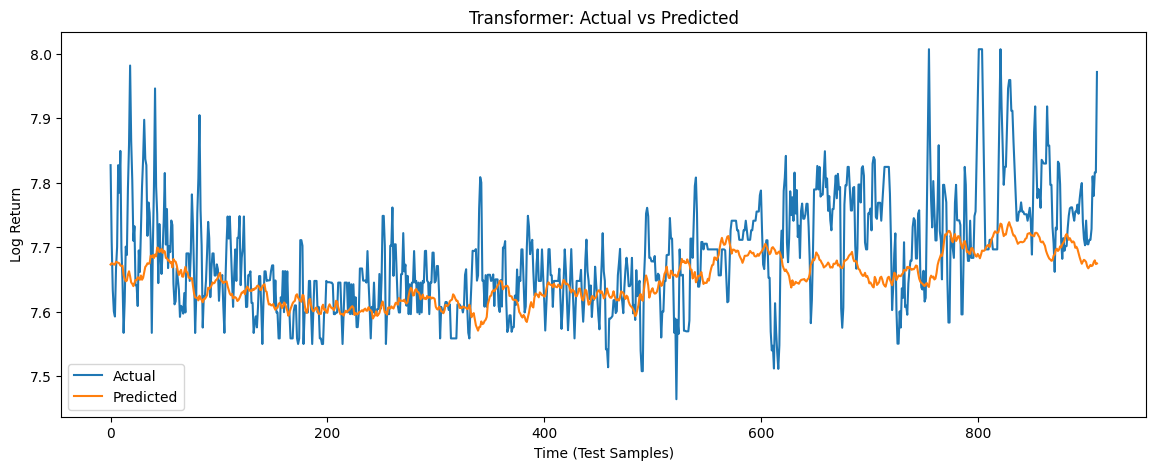

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test_actual, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.xlabel("Time (Test Samples)")
plt.ylabel("Log Return")
plt.title("Transformer: Actual vs Predicted")
plt.legend()
plt.show()


Working on the test data (for this dataset GRU performed best)

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


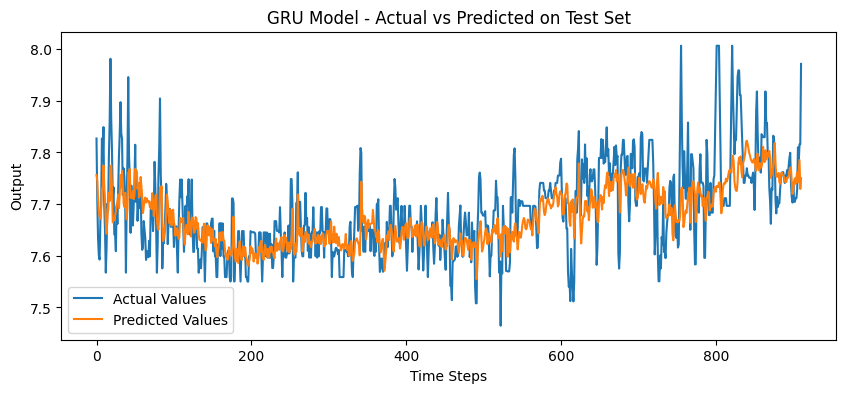

Actual: 7.827  |  Predicted: 7.756
Actual: 7.708  |  Predicted: 7.746
Actual: 7.634  |  Predicted: 7.711
Actual: 7.601  |  Predicted: 7.686
Actual: 7.593  |  Predicted: 7.677
Actual: 7.667  |  Predicted: 7.672
Actual: 7.700  |  Predicted: 7.691
Actual: 7.827  |  Predicted: 7.730
Actual: 7.785  |  Predicted: 7.731
Actual: 7.849  |  Predicted: 7.775
Actual: 7.697  |  Predicted: 7.729
Actual: 7.648  |  Predicted: 7.711
Actual: 7.567  |  Predicted: 7.662
Actual: 7.616  |  Predicted: 7.643
Actual: 7.701  |  Predicted: 7.669
Actual: 7.688  |  Predicted: 7.695
Actual: 7.791  |  Predicted: 7.721
Actual: 7.859  |  Predicted: 7.706
Actual: 7.981  |  Predicted: 7.768
Actual: 7.864  |  Predicted: 7.775
Actual: 7.804  |  Predicted: 7.731
Actual: 7.710  |  Predicted: 7.665
Actual: 7.733  |  Predicted: 7.670
Actual: 7.641  |  Predicted: 7.669
Actual: 7.641  |  Predicted: 7.678
Actual: 7.609  |  Predicted: 7.685
Actual: 7.695  |  Predicted: 7.700
Actual: 7.662  |  Predicted: 7.704
Actual: 7.728  |  Pr

IndexError: index 911 is out of bounds for axis 0 with size 911

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

y_pred_scaled = model_1.predict(X_test_seq)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_vals = scaler_y.inverse_transform(y_test_seq)

y_pred = y_pred.reshape(-1)
y_test_vals = y_test_vals.reshape(-1)

plt.figure(figsize=(10,4))
plt.plot(y_test_vals, label="Actual Values")
plt.plot(y_pred, label="Predicted Values")
plt.title("GRU Model - Actual vs Predicted on Test Set")
plt.xlabel("Time Steps")
plt.ylabel("Output")
plt.legend()
plt.show()


for i in range(1000):
    print(f"Actual: {y_test_vals[i]:.3f}  |  Predicted: {y_pred[i]:.3f}")